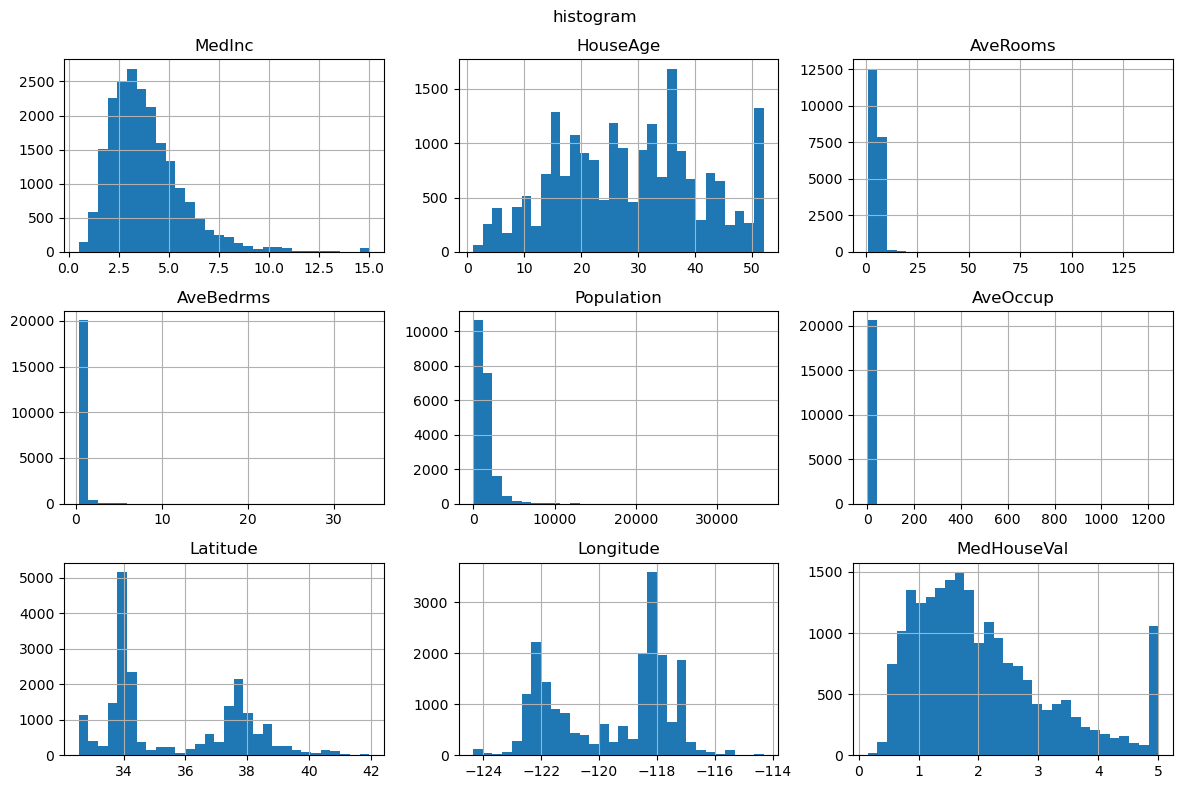

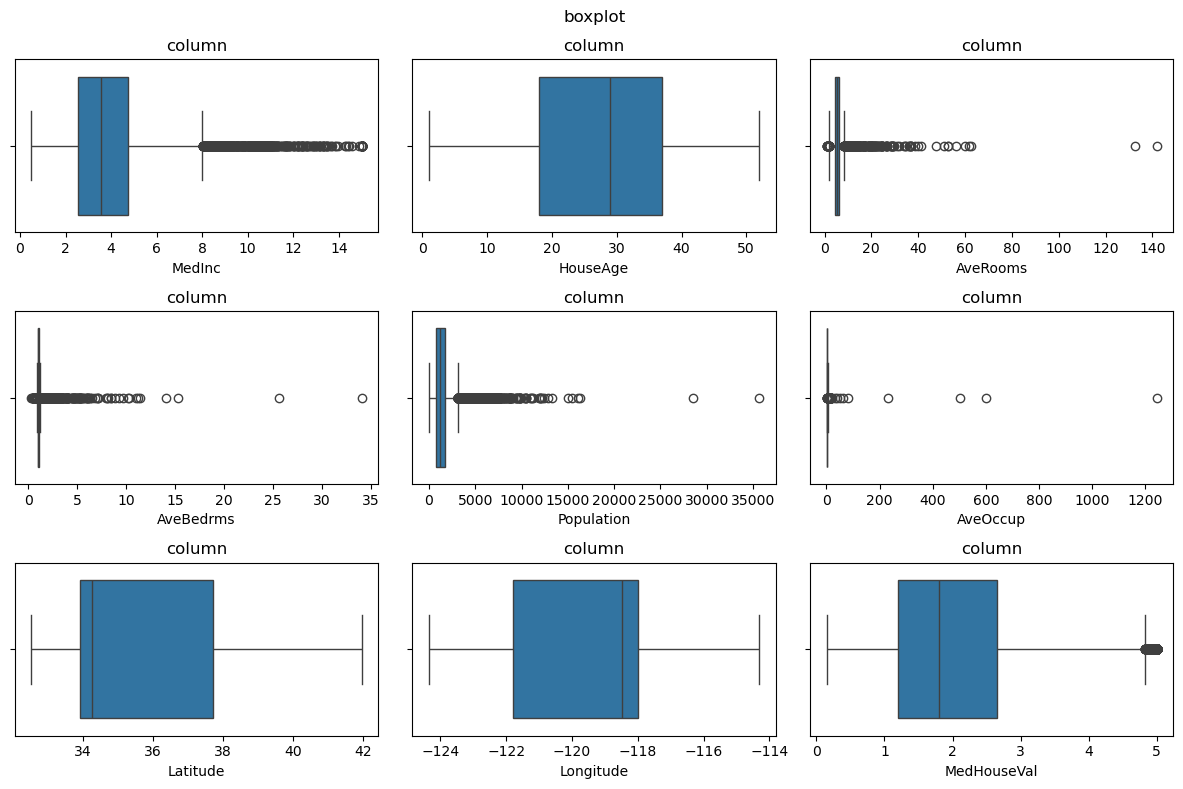

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

df=fetch_california_housing(as_frame=True).frame

df.hist(figsize=(12,8),bins=30,layout=(3,3))
plt.suptitle("histogram")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,8))
for i, col in enumerate(df.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[col])
    plt.title("column")
plt.suptitle("boxplot")
plt.tight_layout()
plt.show()




    


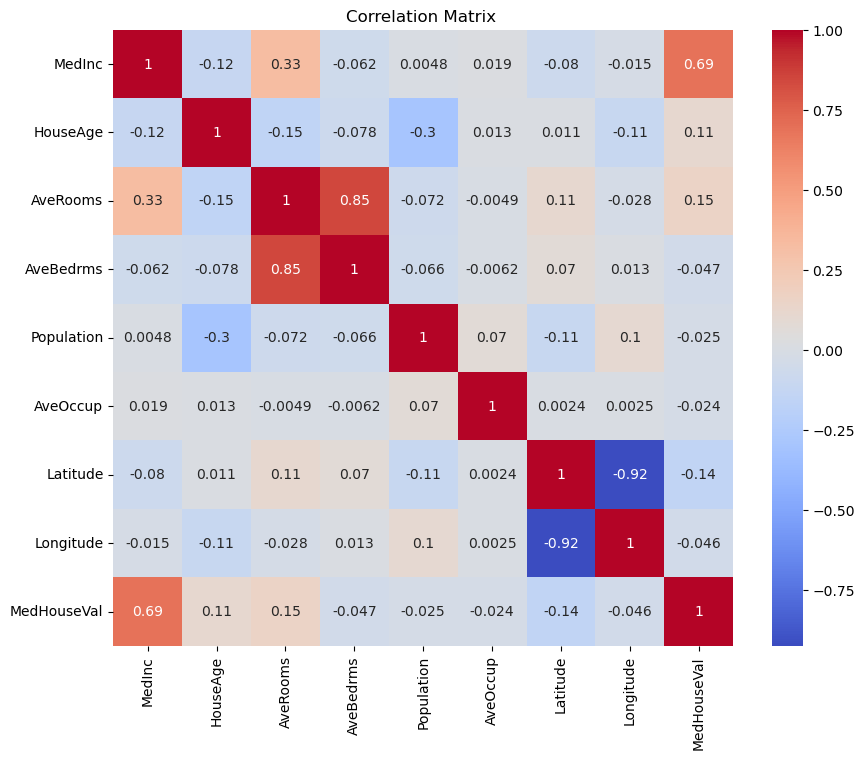

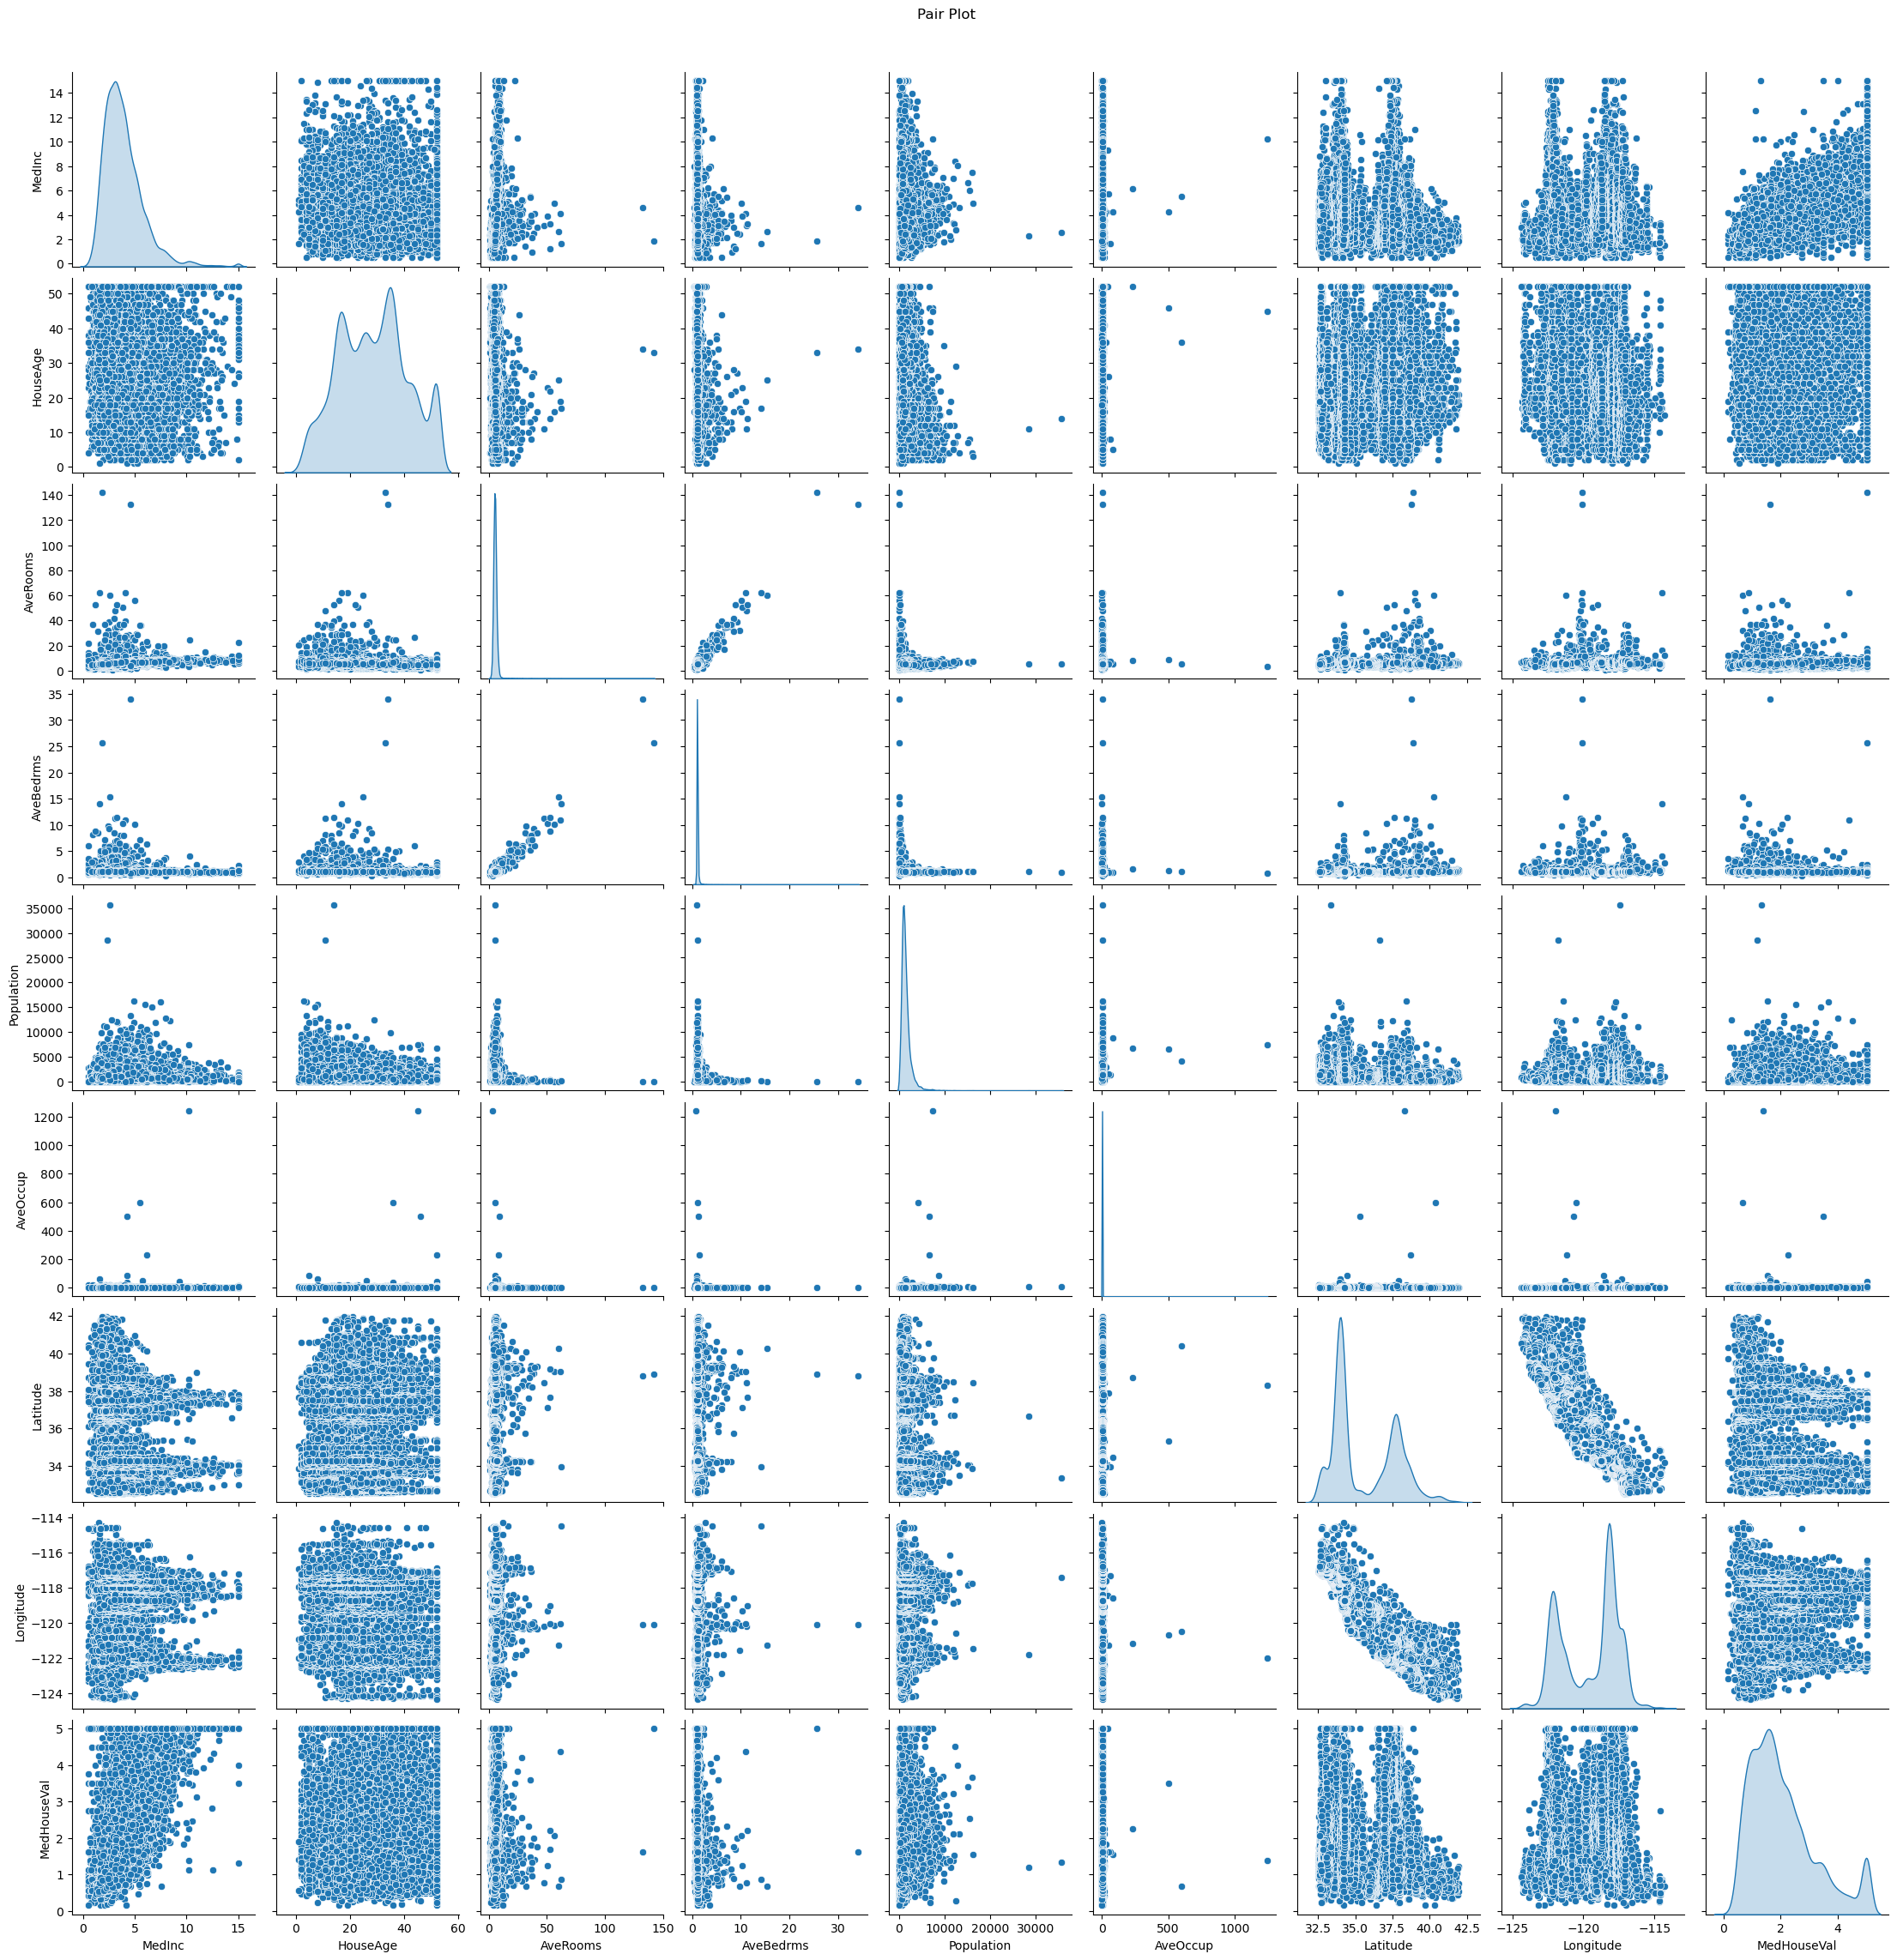

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

df=fetch_california_housing(as_frame=True).frame

cm=df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(cm,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix ')
plt.show()

sns.pairplot(df, diag_kind='kde')
plt.suptitle('Pair Plot ')
plt.show()


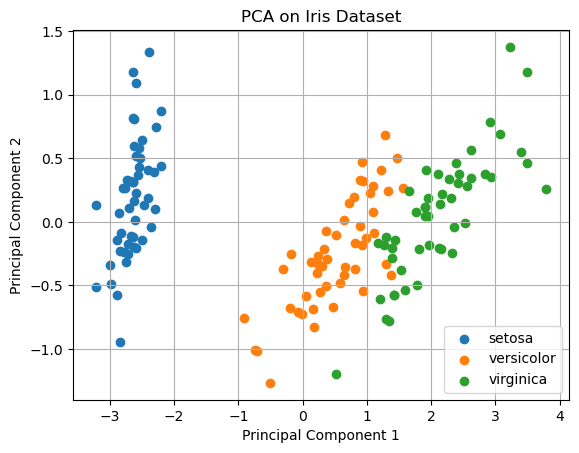

In [15]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
Y = iris.target

pca = PCA(n_components=2).fit_transform(X)

for i in np.unique(Y):
    plt.scatter(
        pca[Y==i,0],
        pca[Y==i,1],
        
        label=iris.target_names[i]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Iris Dataset")
plt.legend()
plt.grid()
plt.show()

In [39]:
import csv
data = list(csv.reader(open('training_data.csv')))
print("Training Data:",data)
hypothesis = data[0][:-1]
for row in data:
    if row[-1] == 'Yes':
        for i in range(len(hypothesis)):
            if hypothesis[i] !=row[i]:
                     hypothesis[i] = '?'
            
                
                
print("output")
print(hypothesis)



Training Data: [['Sunny', 'Warm', 'Normal', 'Strong', 'warm', 'same', 'yes'], ['Sunny', 'warm', 'High', 'Strong', 'warm', 'same', 'yes'], ['Rainy', 'cold', 'High', 'Strong', 'warm', 'change', 'no'], ['Sunny', 'Warm', 'High', 'Strong', '?', 'change', 'yes']]
output
['Sunny', 'Warm', 'Normal', 'Strong', 'warm', 'same']


C:\Users\ADC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Confusion Matrix: [[130  82]
 [  1 356]]

Classification Report:               precision    recall  f1-score   support

           0       0.99      0.61      0.76       212
           1       0.81      1.00      0.90       357

    accuracy                           0.85       569
   macro avg       0.90      0.81      0.83       569
weighted avg       0.88      0.85      0.84       569



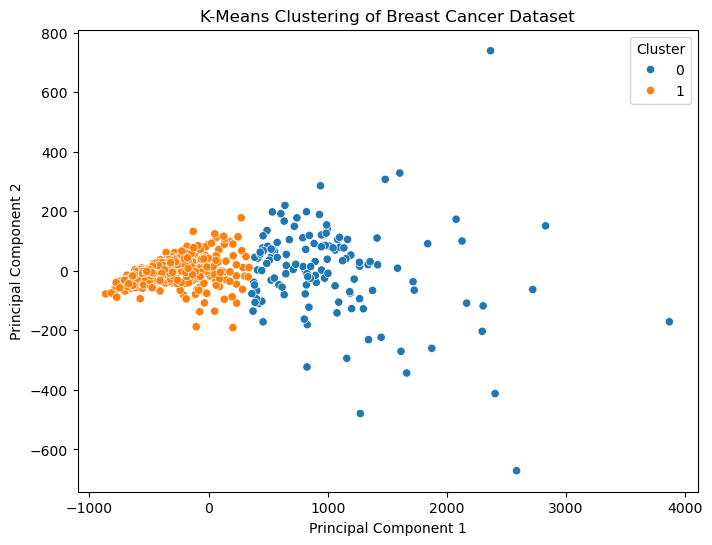

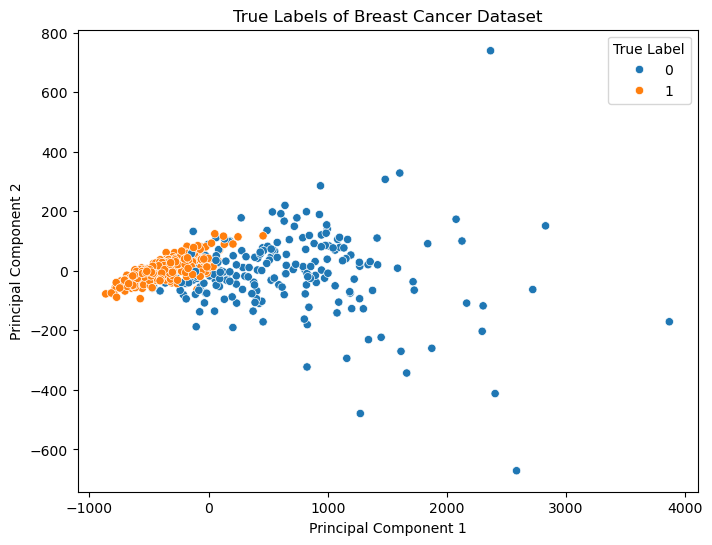

AttributeError: 'numpy.ndarray' object has no attribute 'transform'

<Figure size 800x600 with 0 Axes>

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

print("Confusion Matrix:",confusion_matrix(y, clusters))
print("\nClassification Report:",classification_report(y, clusters))


pca = PCA(n_components=2).fit_transform(X)


plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca[:,0],y=pca[:,1],  hue=clusters)
plt.title('K-Means Clustering of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Cluster")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca[:,0],y=pca[:,1], hue=y)
plt.title('True Labels of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="True Label")
plt.show()

plt.figure(figsize=(8, 6))
centers = pca.transform(kmeans.cluster_centers_)

sns.scatterplot(x=pca[:,0],y=pca[:,1],  hue=clusters)
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering with Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Cluster")
plt.show()

C:\Users\ADC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Confusion Matrix:
[[175  37]
 [ 13 344]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       212
           1       0.90      0.96      0.93       357

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



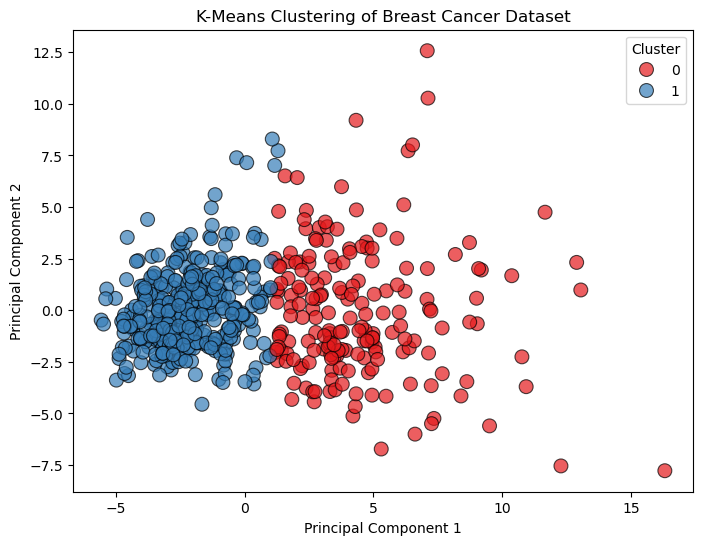

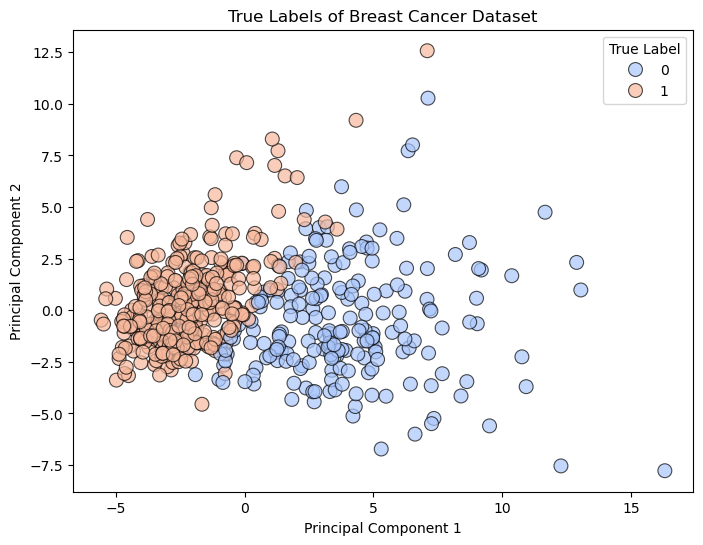

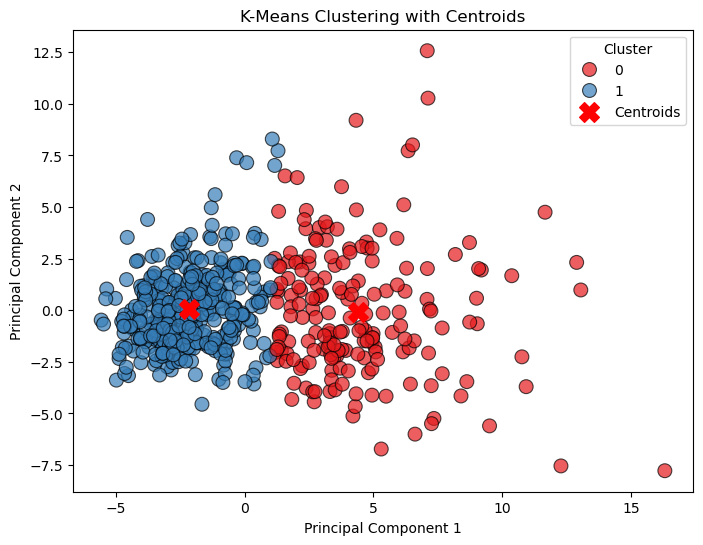

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y, y_kmeans))
print("\nClassification Report:")
print(classification_report(y, y_kmeans))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df['Cluster'] = y_kmeans
df['True Label'] = y

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=100, edgecolor='black', alpha=0.7)
plt.title('K-Means Clustering of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Cluster")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='True Label', palette='coolwarm', s=100, edgecolor='black', alpha=0.7)
plt.title('True Labels of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="True Label")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=100, edgecolor='black', alpha=0.7)
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering with Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Cluster")
plt.show()